# Lección 1: Introducción a Series Temporales — Análisis Exploratorio

**Dataset**: GEFCom2014 — 3 años de carga eléctrica horaria + temperatura (2012-2014)

**Objetivo**: Entender los datos, visualizar patrones (tendencia, estacionalidad, outliers) antes de modelar.

---

## ¿Por qué explorar primero?

Antes de aplicar ARIMA, SVR o cualquier modelo, **siempre** debemos:

1. Ver la forma de los datos (`shape`, columnas, tipos)
2. Detectar valores faltantes
3. Visualizar la serie completa → ¿hay tendencia? ¿estacionalidad?
4. Hacer zoom en períodos cortos → ¿patrones diarios/semanales?
5. Identificar el target (qué queremos predecir)

**Saltarse esto = modelo basura**. La causa #1 de modelos que fallan es no conocer los datos.

## 1. Configuración e imports

In [1]:
# Librerías estándar
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Utilidades del curso (carpeta common/)
from common.utils import load_data

# Configuración visual
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

# Ignorar warnings estéticos
warnings.filterwarnings('ignore')

print("✅ Imports listos")

✅ Imports listos


## 2. Cargar el dataset

La función `load_data()` está en `common/utils.py` y maneja la descarga automática del CSV si no existe.

In [2]:
# Carpeta donde están los datos (relativa a este notebook)
data_dir = './data'

# Cargar TODO el dataset (load + temp)
df = load_data(data_dir)

# Ver estructura
print(f"Forma: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"Tipo índice: {type(df.index)}")
print(f"Rango fechas: {df.index.min()} → {df.index.max()}")

df.head(10)

Forma: (26304, 2)
Columnas: ['load', 'temp']
Tipo índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Rango fechas: 2012-01-01 00:00:00 → 2014-12-31 23:00:00


,load,temp
2012-01-01 00:00:00,2698.0,32.000000
2012-01-01 01:00:00,2558.0,32.666667
2012-01-01 02:00:00,2444.0,30.000000
2012-01-01 03:00:00,2402.0,31.000000
2012-01-01 04:00:00,2403.0,32.000000
2012-01-01 05:00:00,2453.0,31.333333
2012-01-01 06:00:00,2560.0,30.000000
2012-01-01 07:00:00,2719.0,29.000000
2012-01-01 08:00:00,2916.0,29.000000
2012-01-01 09:00:00,3105.0,33.333333


## 3. Exploración básica

### 3.1 Info y tipos de datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2012-01-01 00:00:00 to 2014-12-31 23:00:00
Freq: h
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   load    26304 non-null  float64
 1   temp    26304 non-null  float64
dtypes: float64(2)
memory usage: 616.5 KB


### 3.2 Estadísticas descriptivas

In [4]:
df.describe()

,load,temp
count,26304.000000,26304.000000
mean,3303.769199,47.765638
std,564.579253,19.338142
min,1979.000000,-13.666667
25%,2867.000000,32.666667
50%,3364.000000,48.333333
75%,3690.000000,63.666667
max,5224.000000,95.000000


### 3.3 Valores faltantes

In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())

# ¿Hay gaps en el índice temporal?
expected_hours = (df.index.max() - df.index.min()).total_seconds() / 3600 + 1
print(f"\nHoras esperadas: {int(expected_hours):,}")
print(f"Horas reales:   {len(df):,}")
print(f"Faltantes:      {int(expected_hours - len(df)):,}")

Valores nulos por columna:
load    0
temp    0
dtype: int64

Horas esperadas: 26,304
Horas reales:   26,304
Faltantes:      0


## 4. Visualización: Serie completa (3 años)

Vamos a graficar **carga eléctrica** (`load`) a lo largo de 2012-2014.

**Qué buscar**:
- **Tendencia**: ¿sube, baja, se mantiene?
- **Estacionalidad**: ¿patrones repetitivos (diarios, semanales, anuales)?
- **Outliers**: picos extraños
- **Cambios de régimen**: saltos bruscos

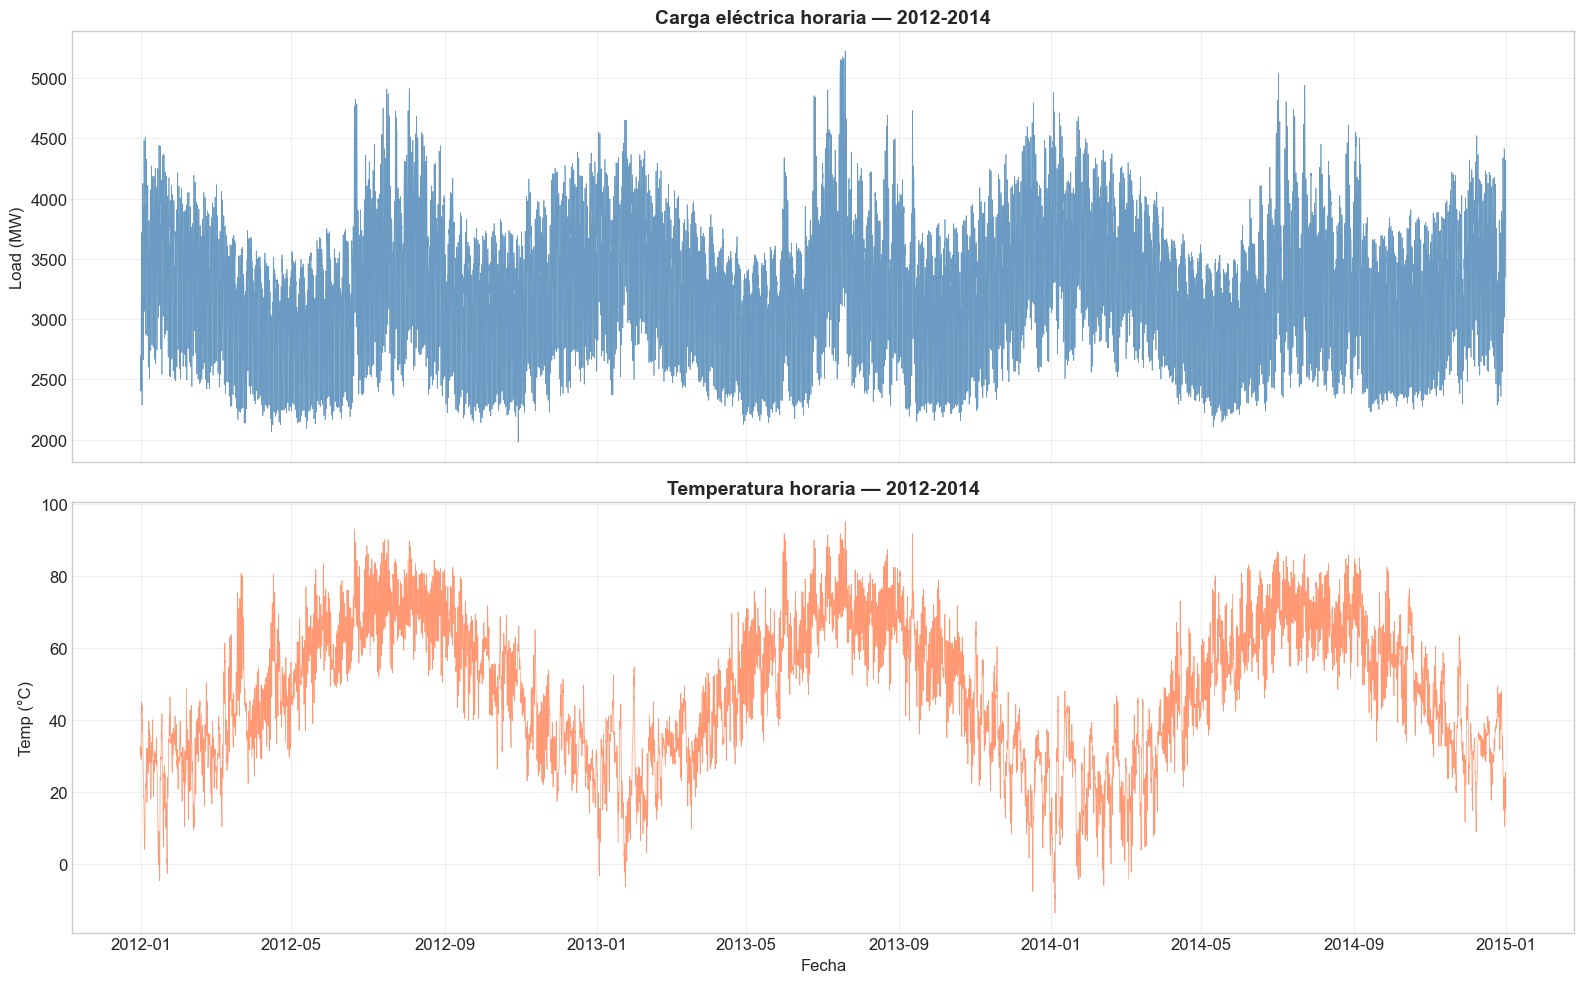

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Carga eléctrica
axes[0].plot(df.index, df['load'], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Carga eléctrica horaria — 2012-2014', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Temperatura
axes[1].plot(df.index, df['temp'], color='coral', linewidth=0.5, alpha=0.8)
axes[1].set_title('Temperatura horaria — 2012-2014', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Temp (°C)', fontsize=12)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Zoom: Primera semana de julio 2014

Ver el patrón **diario** y **semanal** de cerca.

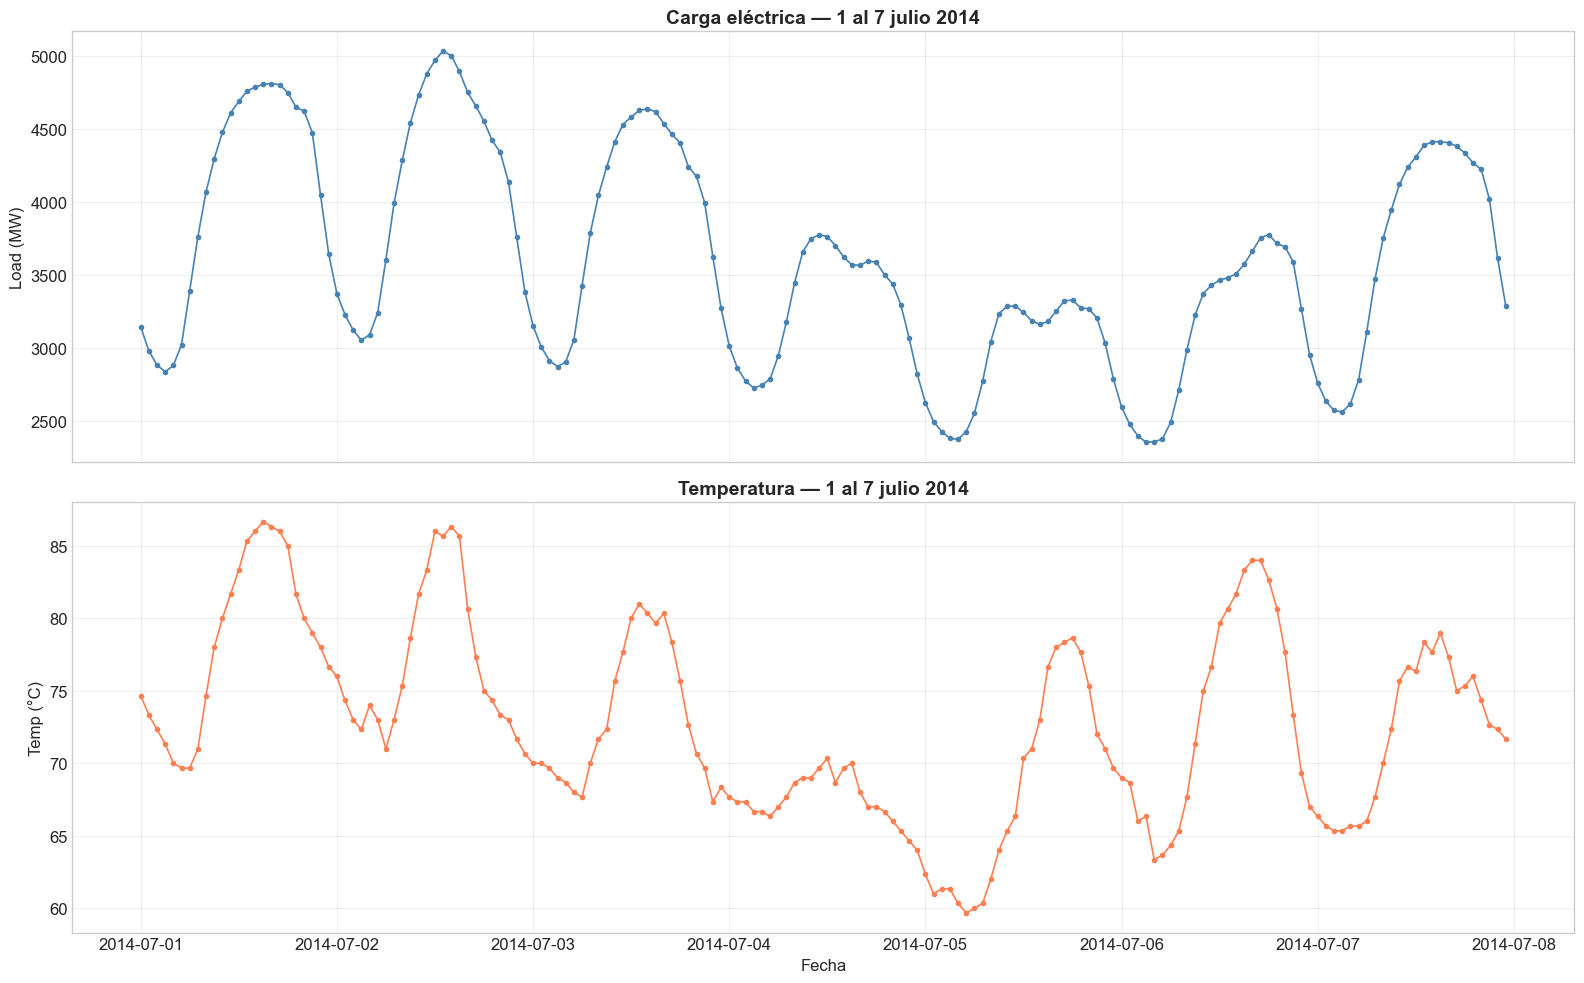

In [7]:
# Filtrar primera semana de julio 2014
july_week = df['2014-07-01':'2014-07-07']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(july_week.index, july_week['load'], color='steelblue', linewidth=1.2, marker='o', markersize=3)
axes[0].set_title('Carga eléctrica — 1 al 7 julio 2014', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(july_week.index, july_week['temp'], color='coral', linewidth=1.2, marker='o', markersize=3)
axes[1].set_title('Temperatura — 1 al 7 julio 2014', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Temp (°C)', fontsize=12)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis de patrones: ¿Qué ves?

### Preguntas para reflexionar (responde en tu cabeza o anota):

1. **Patrón diario**: ¿La carga sube y baja cada 24h? ¿A qué horas picos? ¿Valles?
2. **Patrón semanal**: ¿Días laborables vs fin de semana se nota?
3. **Temperatura vs Carga**: ¿Correlación visual? (verano → A/C → más carga)
4. **Outliers**: ¿Hay puntos que rompen el patrón?
5. **Target**: ¿Qué columna queremos predecir? → **`load`**

Correlación Load ↔ Temperature: 0.073


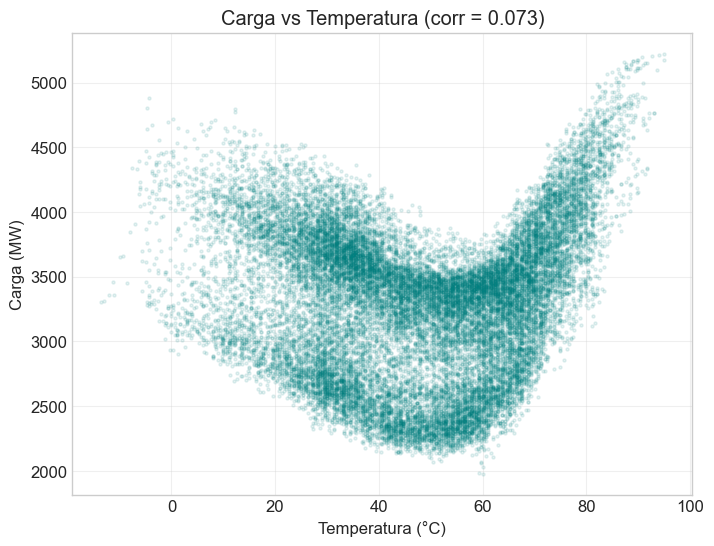

In [8]:
# Correlación carga vs temperatura
corr = df['load'].corr(df['temp'])
print(f"Correlación Load ↔ Temperature: {corr:.3f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['temp'], df['load'], alpha=0.1, s=5, color='teal')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Carga (MW)')
plt.title(f'Carga vs Temperatura (corr = {corr:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Descomposición visual (opcional pero recomendada)

Separar la serie en: **Tendencia + Estacionalidad + Residuo**

In [9]:
# Descomposición estacional simple (requiere statsmodels)
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Usar solo 2014 para que sea más rápido (8760 puntos)
    df_2014 = df['2014']['load']
    
    # Período = 24 (estacionalidad diaria en datos horarios)
    result = seasonal_decompose(df_2014, model='additive', period=24)
    
    fig = result.plot()
    fig.set_size_inches(16, 10)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ statsmodels no instalado. Instala con: pip install statsmodels")
except Exception as e:
    print(f"⚠️ Error en descomposición: {e}")

⚠️ statsmodels no instalado. Instala con: pip install statsmodels


## 8. Resumen: Qué hemos aprendido

| Hallazgo | Qué significa para el modelado |
|----------|--------------------------------|
| **Estacionalidad diaria clara** (24h) | Usar `period=24` en ARIMA/SARIMA |
| **Patrón semanal** (laborable vs fin de semana) | Features de día de semana ayudarán |
| **Correlación temp-carga** | Temperatura como feature exógeno (SARIMAX) |
| **Tendencia suave** (no explosiva) | Diferenciación d=1 probablemente suficiente |
| **Sin gaps mayores** | Serie regular, buena para ARIMA |
| **Outliers moderados** | Modelo robusto o winsorizar |

---

## ✅ Checkpoint listo

**Datos explorados y entendidos.** Listo para la **Lección 2: ARIMA** donde construiremos el primer modelo de pronóstico.

```
Próximo paso → 7-TimeSeries/2-ARIMA/working/notebook.ipynb
```